# Implanter Irradiation Planner

Dose calculator for low-energy ion implantation (e.g., 200 keV He into SiC).
Reads SRIM output files and computes fluence, DPA, at%, irradiation time, and beam heating.

**Key differences from tandem notebook:**
- Saturating at% formula: `C/(n+C)×100` (valid at high implant concentrations)
- Power density tracking (P = I×V / area)
- Current sweep table to find the sweet spot between beam time and sample heating
- Charge state defaults to +1

## Core Functions

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

# ==================== PHYSICS ====================

def fluence_layer(dpa, dpi, n_cm3):
    """Fluence [ions/cm^2] needed for a target DPA."""
    return (dpa * n_cm3) / (dpi * 1e8)

def at_percent(B, Fluence, n):
    """
    Saturating (non-dilute) at% at peak implant depth.
      C = B * Fluence   [implanted atoms/cm^3]
      at% = C / (n + C) * 100
    """
    C = B * Fluence
    return C / (n + C) * 100.0

def beam_power_density(current_nA, energy_keV, slit_mm):
    """Beam heating for a square aperture: P = I*V, density = P/area."""
    area_cm2 = (slit_mm / 10.0) ** 2
    power_W = current_nA * 1e-9 * energy_keV * 1e3
    return {
        "Beam power [W]": power_W,
        "Spot area [cm^2]": area_cm2,
        "Power density [W/cm^2]": power_W / area_cm2
    }

def _beam_flux(current_nA, charge_state, slit_mm):
    """Particle flux [ions/(cm^2*s)] for perpendicular square slit."""
    area_cm2 = (slit_mm / 10.0) ** 2
    return (current_nA / area_cm2) * 1e-9 * 6.242e18 / charge_state

def _fmt_hms(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds - h*3600 - m*60
    return f"{h}h {m}m {s:.1f}s"

# ==================== SRIM PARSERS ====================

def _read_text(p):
    return Path(p).read_text(encoding="latin-1", errors="ignore")

def parse_srim_metadata(folder):
    """
    Extract ion name, energy, and target composition from SRIM output headers.
    Returns dict: {ion, energy_keV, target_elements, target_label}
      e.g. {ion: "He", energy_keV: 200, target_elements: ["Si","C"], target_label: "SiC"}
    """
    folder = Path(folder)
    # Try VACANCY.txt first, fall back to RANGE.txt or E2RECOIL.txt
    for fname in ["VACANCY.txt", "RANGE.txt", "E2RECOIL.txt"]:
        fpath = folder / fname
        if not fpath.exists():
            continue
        text = _read_text(fpath)

        # Line 11-style: "Ion = He   Energy = 200 keV"
        m_ion = re.search(r"Ion\s*=\s*(\w+)\s+Energy\s*=\s*(\d+)\s*keV", text)
        ion = m_ion.group(1) if m_ion else None
        energy = int(m_ion.group(2)) if m_ion else None

        # Target elements: "Layer # 1- Si = 50   Atomic Percent"
        elements = re.findall(r"Layer\s*#\s*\d+-\s*(\w+)\s*=\s*\d+\s+Atomic Percent", text)

        if ion and energy:
            target_label = "".join(elements) if elements else "Target"
            return {
                "ion": ion,
                "energy_keV": energy,
                "target_elements": elements,
                "target_label": target_label
            }

    # Fallback if nothing parsed
    return {"ion": "Ion", "energy_keV": 0, "target_elements": [], "target_label": "Target"}

def parse_atomic_density(e2_path):
    """Read atomic density [atoms/cm^3] from E2RECOIL.txt."""
    m = re.search(r"Density\s*=\s*([0-9.+-Ee]+)\s*atoms/cm3", _read_text(e2_path))
    return float(m.group(1)) if m else None

def parse_DPI_peak(folder):
    """Peak total vacancies (ions+recoils) from VACANCY.txt."""
    p = Path(folder) / "VACANCY.txt"
    mx = None
    data = False
    with p.open(encoding="latin-1", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not data and ("Ang." in s and "IONS" in s and "RECOILS" in s):
                data = True
                next(f, None)
                continue
            if not data:
                continue
            if not s or s[0] in "*;-":
                if mx is not None:
                    break
                continue
            nums = re.findall(r'[-+]?\d+(?:\.\d*)?(?:[EeDd][+-]?\d+)?', s)
            if len(nums) >= 3:
                y = float(nums[1].replace('D','E')) + float(nums[2].replace('D','E'))
                mx = y if mx is None or y > mx else mx
    if mx is None:
        raise ValueError("No data rows found in VACANCY.txt")
    return mx

def parse_B_peak(folder):
    """Peak ion distribution B [1/cm] and depth [angstrom] from RANGE.txt."""
    lines_raw = _read_text(Path(folder) / "RANGE.txt").splitlines(True)
    start = None
    for i, line in enumerate(lines_raw):
        L = line.lower()
        if "ang." in L and "ions" in L and "distribution" in L:
            start = i + 2
            break
    if start is None:
        raise RuntimeError("Could not find distribution table in RANGE.txt")
    df = pd.read_csv(StringIO("".join(lines_raw[start:])),
                     sep=r"\s+", header=None, engine="python")
    df.columns = ["Depth_A", "Ions_Distribution", "Target_Recoils"]
    idx = df["Ions_Distribution"].idxmax()
    return float(df.loc[idx, "Ions_Distribution"]), float(df.loc[idx, "Depth_A"])

def load_srim(folder, override=None):
    """Load n, DPI, B, depth_at_peak from a SRIM output folder."""
    folder = Path(folder)
    n = parse_atomic_density(folder / "E2RECOIL.txt")
    DPI = parse_DPI_peak(folder)
    B, depth_A = parse_B_peak(folder)
    if override:
        n   = override.get("n", n)
        DPI = override.get("DPI", DPI)
        B   = override.get("B", B)
    missing = [k for k, v in {"n": n, "DPI": DPI, "B": B}.items() if v is None]
    if missing:
        raise RuntimeError(f"Missing: {missing}")
    return n, DPI, B, depth_A

## Compute Functions

In [2]:
def compute(folder, dpa_list, current_nA=200.0, charge_state=1.0,
            slit_mm=3.0, energy_keV=None, override=None):
    """Compute fluence, at%, and irradiation time for each target DPA."""
    n, DPI, B, depth_A = load_srim(folder, override)
    dpas     = np.asarray(dpa_list, dtype=float)
    fluences = np.array([fluence_layer(d, DPI, n) for d in dpas])
    atpcts   = np.array([at_percent(B, phi, n) for phi in fluences])
    flux     = _beam_flux(current_nA, charge_state, slit_mm)
    times_s  = fluences / flux

    results = pd.DataFrame({
        "DPA": dpas, "Fluence [ions/cm^2]": fluences, "at%": atpcts,
        "Time [s]": times_s, "Time [h:m:s]": [_fmt_hms(t) for t in times_s]
    })
    meta = {"Atomic density [atoms/cm^3]": n, "DPI [displ/ion]": DPI,
            "B peak [1/cm]": B, "Depth at peak [A]": depth_A,
            "Beam current [nA]": current_nA, "Charge state": charge_state,
            "Slit [mm]": slit_mm, "Flux [ions/(cm^2*s)]": flux}
    if energy_keV is not None:
        pwr = beam_power_density(current_nA, energy_keV, slit_mm)
        meta["Beam energy [keV]"] = energy_keV
        meta.update(pwr)
    return results, pd.Series(meta)


def compute_from_time(folder, time_list_s, current_nA=200.0, charge_state=1.0,
                      slit_mm=3.0, energy_keV=None, override=None):
    """Given irradiation times [s], compute fluence, DPA, and at%."""
    n, DPI, B, depth_A = load_srim(folder, override)
    flux = _beam_flux(current_nA, charge_state, slit_mm)
    rows = []
    for t in time_list_s:
        t = float(t)
        Phi = flux * t
        dpa = (Phi * DPI * 1e8) / n
        rows.append({"Time [s]": t, "Fluence [ions/cm^2]": Phi,
                     "DPA": dpa, "at%": at_percent(B, Phi, n)})
    meta = {"Atomic density [atoms/cm^3]": n, "DPI [displ/ion]": DPI,
            "B peak [1/cm]": B, "Depth at peak [A]": depth_A,
            "Flux [ions/(cm^2*s)]": flux, "Beam current [nA]": current_nA,
            "Charge state": charge_state, "Slit [mm]": slit_mm}
    if energy_keV is not None:
        pwr = beam_power_density(current_nA, energy_keV, slit_mm)
        meta["Beam energy [keV]"] = energy_keV
        meta.update(pwr)
    return pd.DataFrame(rows), pd.Series(meta)


def implanter_plan(folder, dpa_list, energy_keV, slit_mm=5.0,
                   charge_state=1.0, current_range_uA=None,
                   max_power_density=None, override=None):
    """
    Implanter planning table: sweeps beam current showing
    power density and irradiation time for each DPA target.
    """
    if current_range_uA is None:
        current_range_uA = [1, 2, 5, 10, 20, 30, 40, 50]
    n, DPI, B, depth_A = load_srim(folder, override)
    dpas     = np.asarray(dpa_list, dtype=float)
    fluences = np.array([fluence_layer(d, DPI, n) for d in dpas])
    atpcts   = np.array([at_percent(B, phi, n) for phi in fluences])

    rows = []
    for I_uA in current_range_uA:
        I_nA = I_uA * 1000.0
        pwr  = beam_power_density(I_nA, energy_keV, slit_mm)
        flux = _beam_flux(I_nA, charge_state, slit_mm)
        row  = {"Current [uA]": I_uA,
                "Power [W]": pwr["Beam power [W]"],
                "Power density [W/cm^2]": pwr["Power density [W/cm^2]"]}
        for d, phi in zip(dpas, fluences):
            row[f"Time for {d:.1g} DPA"] = _fmt_hms(phi / flux)
        if max_power_density is not None:
            row["OVER LIMIT"] = "!" if pwr["Power density [W/cm^2]"] > max_power_density else ""
        rows.append(row)

    sweep_df = pd.DataFrame(rows)
    dose_df  = pd.DataFrame({"DPA": dpas, "Fluence [ions/cm^2]": fluences, "at%": atpcts})
    meta = pd.Series({
        "Atomic density [atoms/cm^3]": n, "DPI [displ/ion]": DPI,
        "B peak [1/cm]": B, "Depth at peak [A]": depth_A,
        "Beam energy [keV]": energy_keV, "Slit [mm]": slit_mm,
        "Spot area [cm^2]": (slit_mm/10)**2, "Charge state": charge_state})

    print("=== SRIM Parameters ===")
    print(meta.to_string())
    print("\n=== Dose Targets ===")
    print(dose_df.to_string(index=False))
    print("\n=== Current Sweep ===")
    print(sweep_df.to_string(index=False))
    if max_power_density is not None:
        print(f"\n  Power density limit: {max_power_density} W/cm^2")
    return sweep_df, dose_df, meta

## Depth Profile Plots

In [3]:
def plot_depth_profiles(folder, n_atoms, scale_phi=1e16,
                        tail_frac=0.01, pad_frac=0.05):
    """Twin-y plot of DPA and ion at% vs depth. Uses saturating at%.
    Titles auto-generated from SRIM file headers."""
    meta = parse_srim_metadata(folder)
    ion = meta["ion"]
    energy = meta["energy_keV"]
    target = meta["target_label"]

    def fnum(x):
        return float(x.replace('D','E'))

    # VACANCY.txt -> DPA
    vac_rows = []
    with open(f"{folder}/VACANCY.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: vac_rows.append((fnum(p[0]), fnum(p[1]), fnum(p[2])))
                except ValueError: continue
    vac = pd.DataFrame(vac_rows, columns=["Depth_A","Vac_Ions","Vac_Recoils"])
    vac["Depth_um"]  = vac["Depth_A"] * 1e-4
    vac["Vac_Total"] = vac["Vac_Ions"] + vac["Vac_Recoils"]
    vac["DPA"]       = scale_phi * vac["Vac_Total"] * 1e8 / n_atoms

    # RANGE.txt -> at%
    rng_rows = []
    with open(f"{folder}/RANGE.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: rng_rows.append((fnum(p[0]), fnum(p[1])))
                except ValueError: continue
    rng = pd.DataFrame(rng_rows, columns=["Depth_A","B_per_cm"])
    rng["Depth_um"] = rng["Depth_A"] * 1e-4
    C = scale_phi * rng["B_per_cm"]
    rng["atpct"] = C / (n_atoms + C) * 100.0

    # x-range
    def tail_x(depth, y):
        ya = np.asarray(y)
        peak = np.nanmax(ya)
        if peak <= 0: return float(depth.max())
        idx = np.where(ya > peak * tail_frac)[0]
        return float(depth.iloc[idx[-1]]) if len(idx) else float(depth.max())

    xmax = max(tail_x(vac["Depth_um"], vac["DPA"]),
               tail_x(rng["Depth_um"], rng["atpct"]))
    xmax = min(xmax * (1 + pad_frac),
               max(vac["Depth_um"].max(), rng["Depth_um"].max()))

    fig, ax1 = plt.subplots(figsize=(9, 5))
    l1, = ax1.plot(vac["Depth_um"], vac["DPA"], lw=2,
                   label=f"DPA per {scale_phi:.0e} ions/cm\u00b2")
    ax1.set_xlabel("Depth (\u00b5m)")
    ax1.set_ylabel(f"DPA per {scale_phi:.0e} ions/cm\u00b2")
    ax1.grid(True)

    ax2 = ax1.twinx()
    l2, = ax2.plot(rng["Depth_um"], rng["atpct"], lw=2, ls="--",
                   label=f"{ion} at% per {scale_phi:.0e} ions/cm\u00b2")
    ax2.set_ylabel(f"{ion} at% per {scale_phi:.0e} ions/cm\u00b2")
    ax1.set_xlim(0, xmax)
    ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="best")
    plt.title(f"{energy} keV {ion} \u2192 {target}: DPA and {ion} at% vs Depth")
    plt.tight_layout()
    plt.show()
    return vac, rng


def plot_vacancy_profile(folder, title=None):
    """Plot vacancy depth profile from VACANCY.txt.
    Title auto-generated from SRIM headers if not provided."""
    if title is None:
        meta = parse_srim_metadata(folder)
        title = f"{meta['energy_keV']} keV {meta['ion']} \u2192 {meta['target_label']}: Vacancy Production vs Depth"

    rows = []
    with open(f"{folder}/VACANCY.txt", "r", errors="ignore") as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:
                try: rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
                except ValueError: continue
    df = pd.DataFrame(rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
    df["Depth_um"] = df["Depth_A"] * 1e-4
    df["Total"] = df["Vac_Ions"] + df["Vac_Recoils"]

    plt.figure(figsize=(10, 6))
    plt.plot(df["Depth_um"], df["Vac_Ions"], label="Vacancies by Ions", lw=2)
    plt.plot(df["Depth_um"], df["Vac_Recoils"], color="gray", label="Vacancies by Recoils", lw=2)
    plt.plot(df["Depth_um"], df["Total"], color="orange", label="Total", lw=2)
    plt.xlabel("Depth (\u00b5m)")
    plt.ylabel("Vacancies / (\u00c5\u00b7Ion)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df

---
## Example

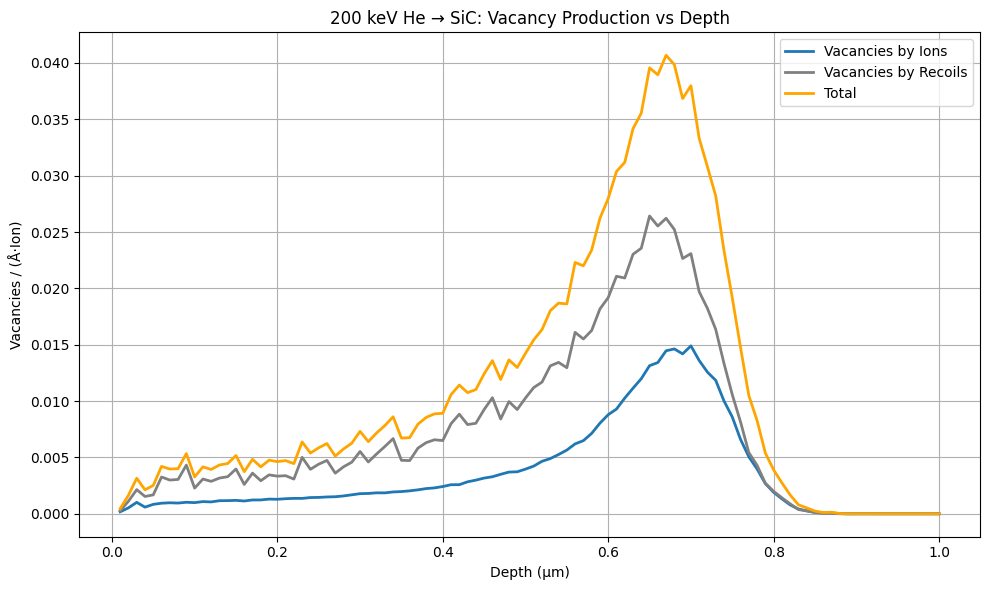

,Depth_A,Vac_Ions,Vac_Recoils,Depth_um,Total
0,100.01,0.000176,0.000276,0.010001,0.000452
1,200.01,0.000530,0.001116,0.020001,0.001646
2,300.01,0.001014,0.002142,0.030001,0.003156
3,400.01,0.000590,0.001537,0.040001,0.002127
4,500.01,0.000838,0.001679,0.050001,0.002517
...,...,...,...,...,...
95,9600.01,0.000000,0.000000,0.960001,0.000000
96,9700.01,0.000000,0.000000,0.970001,0.000000
97,9800.01,0.000000,0.000000,0.980001,0.000000
98,9900.01,0.000000,0.000000,0.990001,0.000000


In [6]:
FOLDER = "HelionSiC/200keVHe/"

# Vacancy profile (title auto-generated from SRIM headers)
plot_vacancy_profile(FOLDER)

Atomic density: 9.611e+22 atoms/cm^3


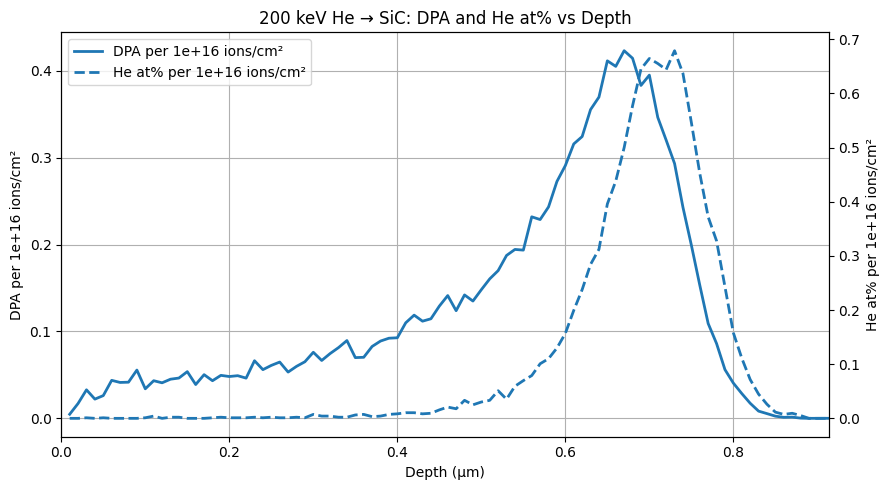

In [7]:
# DPA + at% depth profiles (per 1e16 ions/cm^2, titles auto-generated)
n_SiC = parse_atomic_density(Path(FOLDER) / "E2RECOIL.txt")
print(f"Atomic density: {n_SiC:.3e} atoms/cm^3")
vac, rng = plot_depth_profiles(FOLDER, n_atoms=n_SiC, scale_phi=1e16)

In [8]:
# Implanter planning: current sweep with 30 W/cm^2 heating limit
sweep, doses, meta = implanter_plan(
    folder=FOLDER,
    dpa_list=[1,10,100],
    energy_keV=200,
    slit_mm=3,
    charge_state=1,
    max_power_density=30       # W/cm^2 limit for 800C irradiation
)

=== SRIM Parameters ===
Atomic density [atoms/cm^3]    9.611000e+22
DPI [displ/ion]                4.068230e-02
B peak [1/cm]                  6.570100e+04
Depth at peak [A]              7.300010e+03
Beam energy [keV]              2.000000e+02
Slit [mm]                      3.000000e+00
Spot area [cm^2]               9.000000e-02
Charge state                   1.000000e+00

=== Dose Targets ===
  DPA  Fluence [ions/cm^2]       at%
  1.0         2.362452e+16  1.589311
 10.0         2.362452e+17 13.904267
100.0         2.362452e+18 61.758753

=== Current Sweep ===
 Current [uA]  Power [W]  Power density [W/cm^2] Time for 1 DPA Time for 1e+01 DPA Time for 1e+02 DPA OVER LIMIT
            1        0.2                2.222222    0h 5m 40.6s       0h 56m 46.3s       9h 27m 42.9s           
            2        0.4                4.444444    0h 2m 50.3s       0h 28m 23.1s       4h 43m 51.5s           
            5        1.0               11.111111     0h 1m 8.1s       0h 11m 21.3s       1h 

In [38]:
# Specific irradiation plan (pick your current from the sweep above)
results, meta = compute(
    folder=FOLDER,
    dpa_list=[1,10,100],
    current_nA=10000,          # 10 uA
    charge_state=1,
    slit_mm=3,
    energy_keV=200
)
print(meta.to_string())
print()
print(results.to_string(index=False))

Atomic density [atoms/cm^3]    9.611000e+22
DPI [displ/ion]                4.694120e-03
B peak [1/cm]                  8.505100e+04
Depth at peak [A]              1.220000e+04
Beam current [nA]              1.000000e+04
Charge state                   1.000000e+00
Slit [mm]                      3.000000e+00
Flux [ions/(cm^2*s)]           6.935556e+14
Beam energy [keV]              2.000000e+02
Beam power [W]                 2.000000e+00
Spot area [cm^2]               9.000000e-02
Power density [W/cm^2]         2.222222e+01

  DPA  Fluence [ions/cm^2]       at%     Time [s] Time [h:m:s]
  1.0         2.047455e+17 15.339346   295.211407  0h 4m 55.2s
 10.0         2.047455e+18 64.436383  2952.114070 0h 49m 12.1s
100.0         2.047455e+19 94.769498 29521.140703  8h 12m 1.1s


In [39]:
# Time-driven: what dose do I get after X seconds?
results_t, meta_t = compute_from_time(
    folder=FOLDER,
    time_list_s=[300, 3600, 36000],    # 5 min, 1 hr, 10 hr
    current_nA=10000,
    charge_state=1,
    slit_mm=3,
    energy_keV=200
)
print(meta_t.to_string())
print()
print(results_t.to_string(index=False))

Atomic density [atoms/cm^3]    9.611000e+22
DPI [displ/ion]                4.694120e-03
B peak [1/cm]                  8.505100e+04
Depth at peak [A]              1.220000e+04
Flux [ions/(cm^2*s)]           6.935556e+14
Beam current [nA]              1.000000e+04
Charge state                   1.000000e+00
Slit [mm]                      3.000000e+00
Beam energy [keV]              2.000000e+02
Beam power [W]                 2.000000e+00
Spot area [cm^2]               9.000000e-02
Power density [W/cm^2]         2.222222e+01

 Time [s]  Fluence [ions/cm^2]        DPA       at%
    300.0         2.080667e+17   1.016221 15.549474
   3600.0         2.496800e+18  12.194651 68.842528
  36000.0         2.496800e+19 121.946507 95.670064
